# DDM with hierarchical regressions

Generate synthetic data from a DDM with known parameters, then fit it back with HSSM.

Three variants build up the regression complexity on drift rate **v**:

- **A.** within-subject: `v ~ 0 + x + (1 + x | participant_id)`
- **B.** between and within: `v ~ 0 + age + x + (1 + x | participant_id)`
- **C.** interaction: `v ~ 0 + age + x + age:x + (1 + x | participant_id)`

In Variants A–C the other parameters (a, z, t) are estimated globally (`param ~ 1`), keeping the focus on the v regression.

A final **Variant D** adds hierarchy to every parameter (`param ~ 1 + (1 | participant_id)`) to demonstrate the fully hierarchical global case.

In [1]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import pymc as pm
import hssm

rng = np.random.default_rng(0)

You supplied a model 'racing_diffusion_3', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.
You supplied a model 'poisson_race', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


## Covariates

10 participants, 250 trials each. `x` is trial-level (think task difficulty, standardized). `age` is one value per participant (standardized). `rt` and `response` start as placeholders and get filled in after simulation.

In [2]:
n_participants = 10
n_trials = 250

pid = np.repeat(np.arange(n_participants), n_trials)
x = rng.normal(0, 1, size=n_participants * n_trials)
age_by_p = rng.normal(0, 1, size=n_participants)
age = age_by_p[pid]

covariates = pd.DataFrame({
    "participant_id": pid,
    "x": x,
    "age": age,
    "rt": np.nan,
    "response": np.nan,
})
covariates.head()

,participant_id,x,age,rt,response
0,0,0.125730,-0.858436,NaN,NaN
1,0,-0.132105,-0.858436,NaN,NaN
2,0,0.640423,-0.858436,NaN,NaN
3,0,0.104900,-0.858436,NaN,NaN
4,0,-0.535669,-0.858436,NaN,NaN


## Variant A: within-subject

Drift rate depends on trial-level `x`. Each participant has their own intercept and slope for `x`.

The other parameters (a, z, t) are estimated as **global scalars** — no hierarchy, no regression — so the model stays focused on the v structure.

Pick the ground-truth coefficients, draw per-participant random effects for v, and compute v for every trial.

We then use the **do-operator** (`model.sample_do`) to intervene on the DDM’s parameters and forward-simulate synthetic data through the model’s likelihood. Because a, z, t are modelled globally in this variant, we simulate them as scalars.

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()


Model initialized successfully.


Sampling: [rt,response]


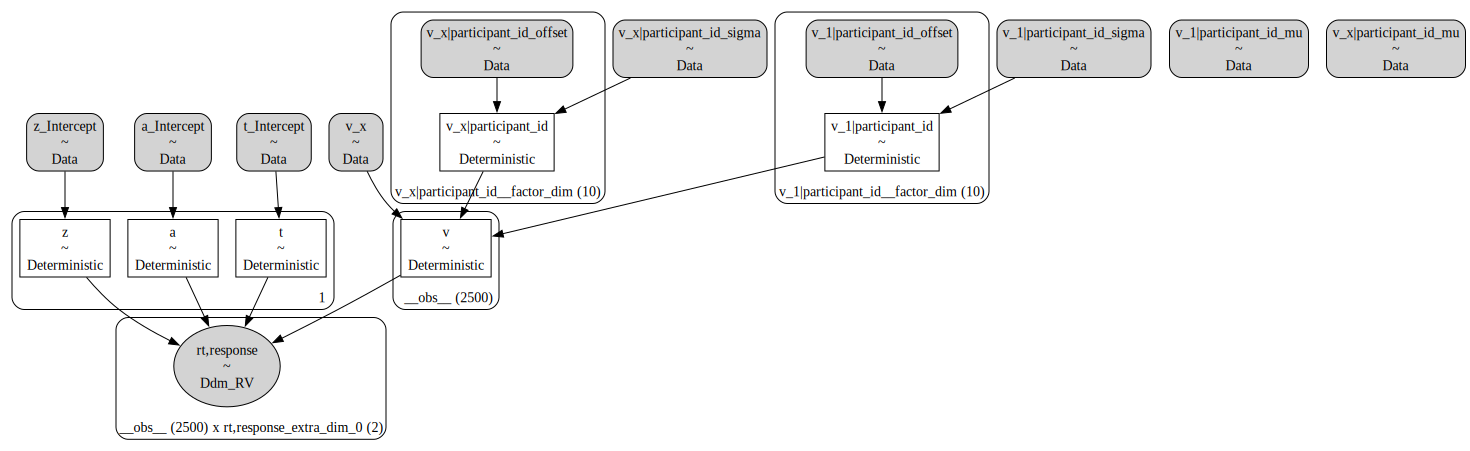

In [ ]:
# true coefficients for variant A
beta_v_x = 0.8
sigma_v_int, sigma_v_slope = 0.3, 0.2

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)

a_true, z_true, t_true = 1.2, 0.5, 0.25

# Noncentered offsets for the random effects
v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_A_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[{"name": "v", "formula": "v ~ 0 + x + (1 + x | participant_id)"}],
    noncentered=True,
)

# Use do-operator
synth_idata_A, synth_model_A = model_A_gen.sample_do(
    params={
        "v_x": beta_v_x,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_x|participant_id_mu": 0.0,
        "v_x|participant_id_sigma": sigma_v_slope,
        "v_x|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    return_model=True,
)

pm.model_to_graphviz(synth_model_A)

In [4]:
synth_df_A = hssm.utils.predictive_idata_to_dataframe(
    synth_idata_A, predictive_group="prior_predictive"
)

data_A = covariates.copy()
data_A["rt"] = synth_df_A["rt"].values
data_A["response"] = synth_df_A["response"].values

data_A.to_csv("sim_variant_A.csv", index=False)
data_A.head()

,participant_id,x,age,rt,response
0,0,0.125730,-0.858436,1.863500,-1.0
1,0,-0.132105,-0.858436,1.903266,-1.0
2,0,0.640423,-0.858436,0.830093,-1.0
3,0,0.104900,-0.858436,1.133656,1.0
4,0,-0.535669,-0.858436,1.242878,-1.0


Reload the saved data and fit a fresh model with the same regression.

In [5]:
data_A = pd.read_csv("sim_variant_A.csv")

model_A = hssm.HSSM(
    data=data_A,
    model="ddm",
    global_formula="y ~ 1",
    include=[{"name": "v", "formula": "v ~ 0 + x + (1 + x | participant_id)"}],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.
Model initialized successfully.


Sanity-check the model before sampling: the textual description shows every parameter's formula, and the graph gives the plate diagram.

Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + x + (1 + x | participant_id)
    Priors:
        v_x ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_x|participant_id ~ Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)
    Link: identity
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


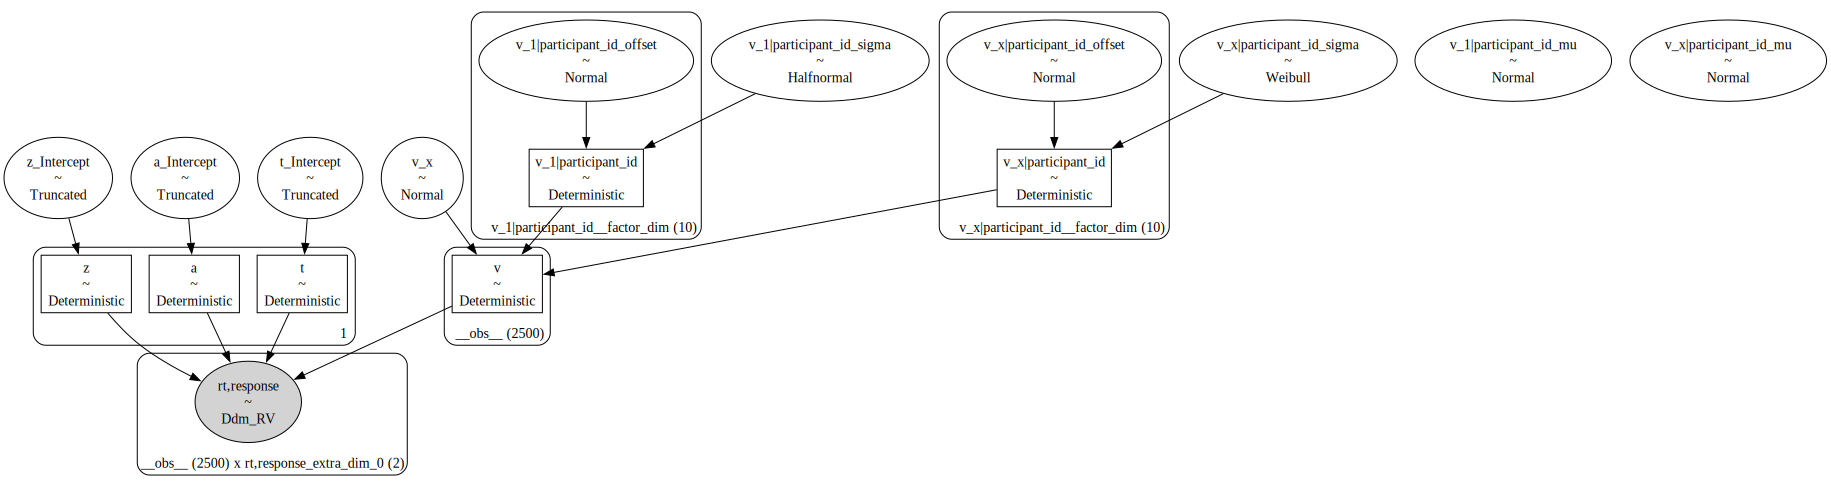

In [6]:
print(model_A)
model_A.graph()

In [7]:
idata_A = model_A.sample(draws=1000, tune=500, chains=2, target_accept=0.9)

Using default initvals. 



Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [v_x, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_x|participant_id_mu, v_x|participant_id_sigma, v_x|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]
/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 104 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
100%|██████████| 2000/2000 [00:01<00:00, 1341.79it/s]


First look at *all* estimated variables (no `var_names` filter) — this is how you discover the participant-wise parameters needed for recovery checks.

In [8]:
az.summary(idata_A)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_Intercept,0.506,0.007,0.493,0.519,0.000,0.000,1820.0,1580.0,1.00
v_1|participant_id_mu,1.999,2.959,-3.055,7.965,0.059,0.073,2498.0,1422.0,1.00
v_x|participant_id_mu,-0.001,0.256,-0.461,0.514,0.005,0.006,2840.0,1556.0,1.00
v_1|participant_id_offset[0],-0.379,0.200,-0.759,-0.032,0.006,0.006,1206.0,1189.0,1.01
v_1|participant_id_offset[1],-0.104,0.179,-0.476,0.215,0.005,0.006,1500.0,1061.0,1.00
v_1|participant_id_offset[2],1.577,0.413,0.827,2.325,0.023,0.011,317.0,763.0,1.02
v_1|participant_id_offset[3],-1.022,0.291,-1.601,-0.524,0.016,0.008,335.0,815.0,1.01
v_1|participant_id_offset[4],-0.507,0.207,-0.895,-0.118,0.008,0.006,775.0,881.0,1.01
v_1|participant_id_offset[5],-0.461,0.213,-0.848,-0.088,0.008,0.006,827.0,1046.0,1.00
v_1|participant_id_offset[6],-0.620,0.226,-1.033,-0.208,0.010,0.006,502.0,822.0,1.00


Now filter to the key global coefficients.

In [9]:
az.summary(idata_A, var_names=["v_x", "a_Intercept", "z_Intercept", "t_Intercept"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_x,0.721,0.058,0.613,0.824,0.002,0.002,623.0,729.0,1.0
a_Intercept,1.194,0.015,1.166,1.221,0.000,0.000,1774.0,1434.0,1.0
z_Intercept,0.506,0.007,0.493,0.519,0.000,0.000,1820.0,1580.0,1.0
t_Intercept,0.263,0.008,0.247,0.277,0.000,0.000,1592.0,1396.0,1.0


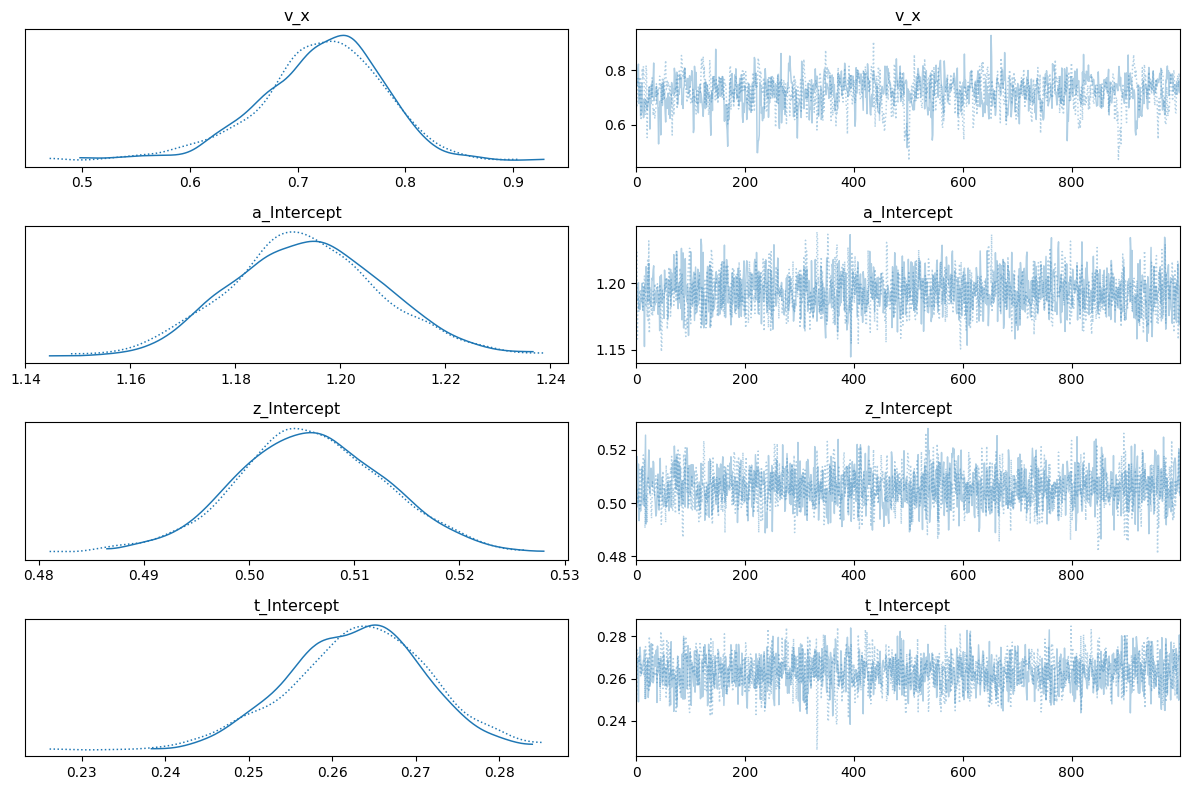

In [10]:
az.plot_trace(idata_A, var_names=["v_x", "a_Intercept", "z_Intercept", "t_Intercept"])
plt.tight_layout();

Posterior predictive check — validate in data space that the fitted model can reproduce the observed RT distributions.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided InferenceData object and the original data. This will modify the provided InferenceData object, or if not provided, the traces object stored inside the model.


<Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Response Time', ylabel='Density'>

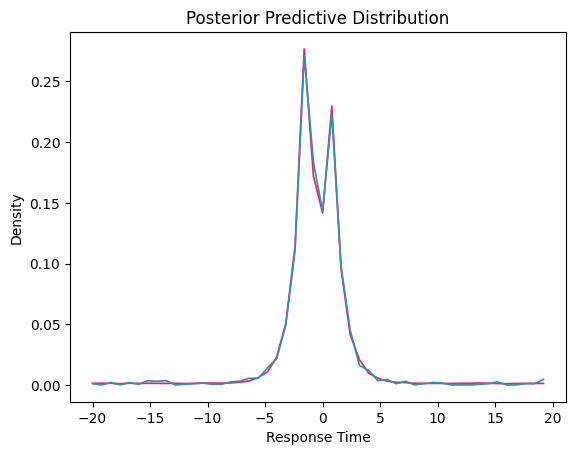

In [11]:
hssm.plotting.plot_predictive(model_A, col_wrap=5)

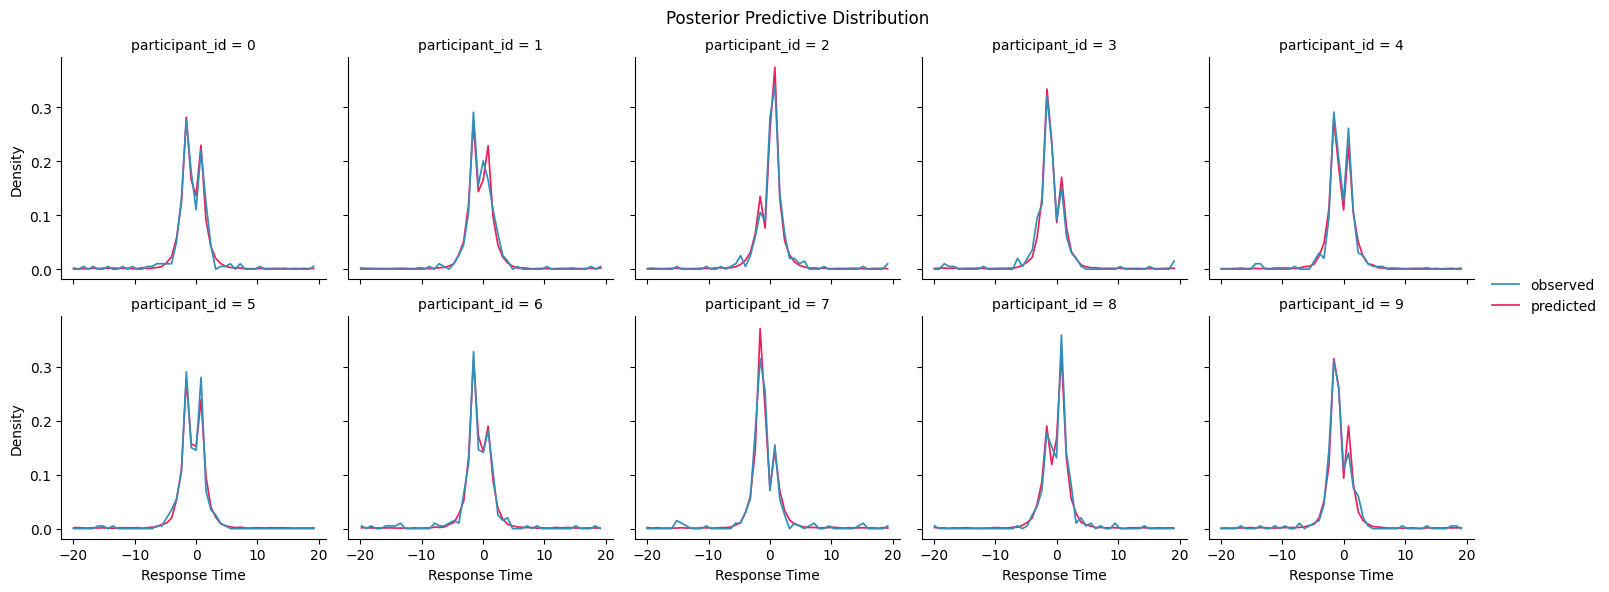

In [12]:
hssm.plotting.plot_predictive(model_A, col="participant_id", col_wrap=5)

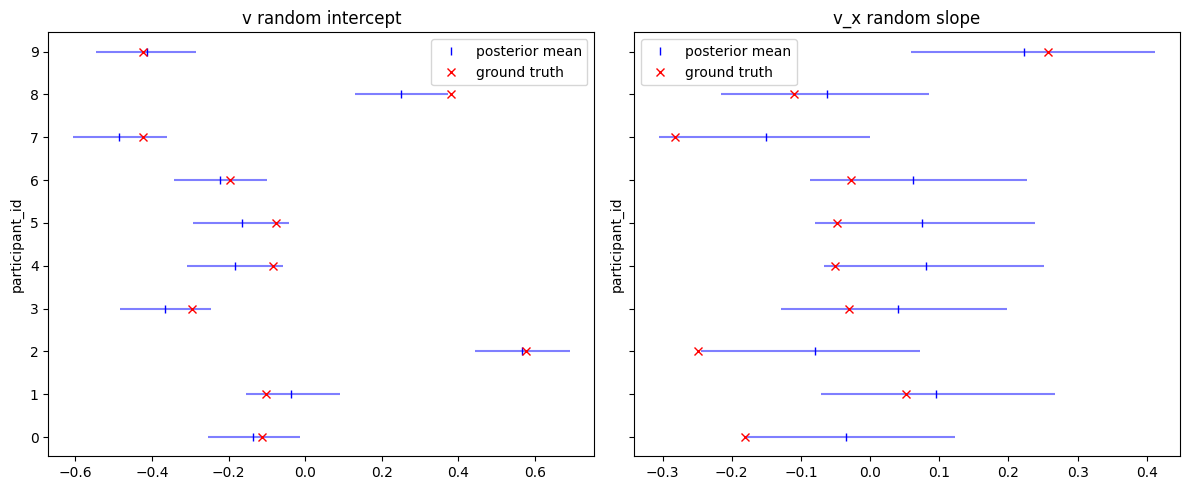

In [13]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_x|participant_id", v_slope_p, "v_x random slope"),
    ],
):
    post = idata_A.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, hdi_prob=0.95)[param_name].values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()

## Variant B: between and within

Same within-subject story on `x`, plus a between-subject effect of `age` on the drift rate.

a, z, t remain global scalars.

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()


Model initialized successfully.


Sampling: [rt,response]


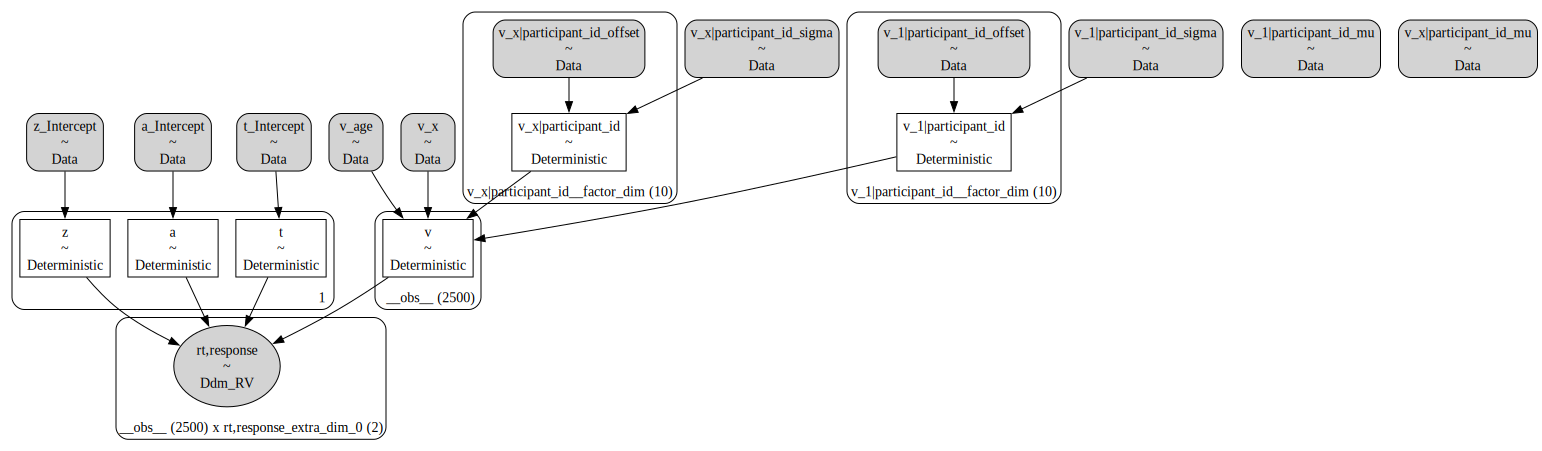

In [14]:
# true coefficients for variant B
beta_v_x = 0.8
beta_v_age = 0.4

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)

v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_B_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[{"name": "v", "formula": "v ~ 0 + age + x + (1 + x | participant_id)"}],
    noncentered=True,
)

# Use do-operator: intervene on regression coefficients and random effects
synth_idata_B, synth_model_B = model_B_gen.sample_do(
    params={
        "v_age": beta_v_age,
        "v_x": beta_v_x,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_x|participant_id_mu": 0.0,
        "v_x|participant_id_sigma": sigma_v_slope,
        "v_x|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    return_model=True,
)

pm.model_to_graphviz(synth_model_B)

In [15]:
synth_df_B = hssm.utils.predictive_idata_to_dataframe(
    synth_idata_B, predictive_group="prior_predictive"
)

data_B = covariates.copy()
data_B["rt"] = synth_df_B["rt"].values
data_B["response"] = synth_df_B["response"].values
data_B.to_csv("sim_variant_B.csv", index=False)

In [16]:
data_B = pd.read_csv("sim_variant_B.csv")

model_B = hssm.HSSM(
    data=data_B,
    model="ddm",
    global_formula="y ~ 1",
    include=[{"name": "v", "formula": "v ~ 0 + age + x + (1 + x | participant_id)"}],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.
Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + age + x + (1 + x | participant_id)
    Priors:
        v_age ~ Normal(mu: 0.0, sigma: 0.25)
        v_x ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_x|participant_id ~ Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)
    Link: identity
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse d

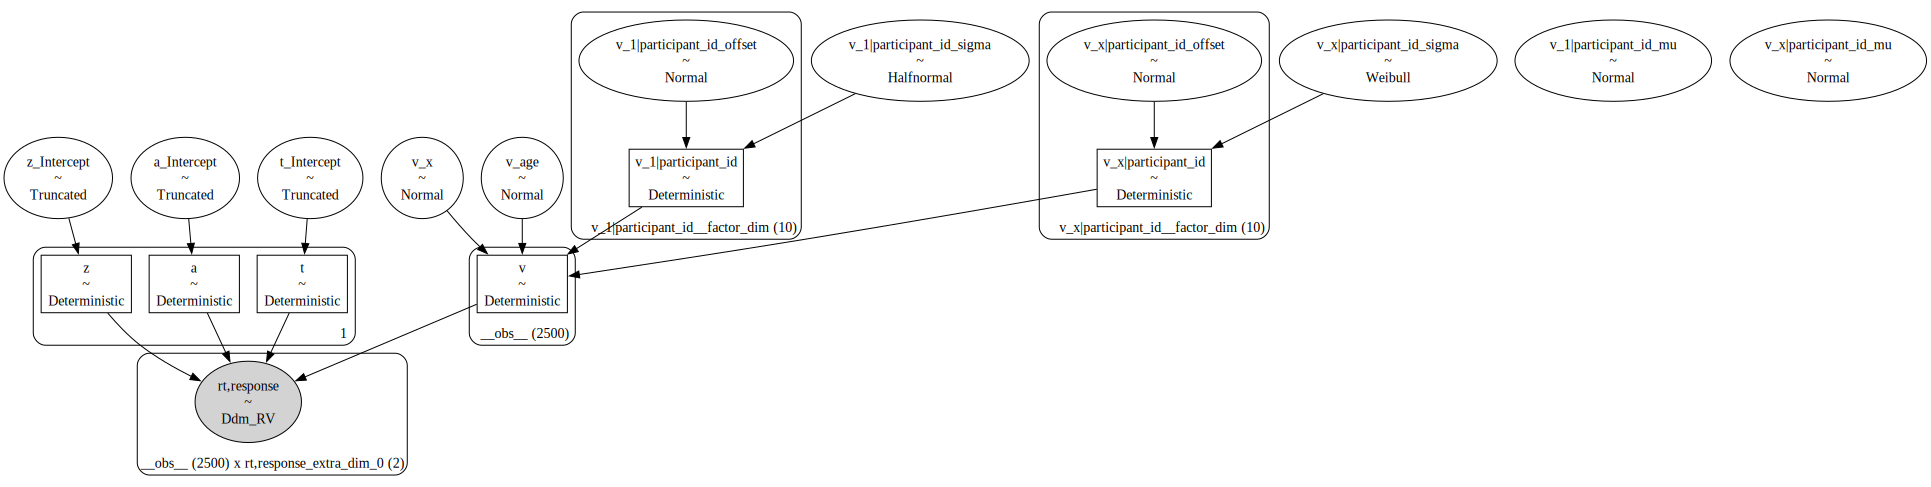

In [17]:
print(model_B)
model_B.graph()

In [18]:
idata_B = model_B.sample(draws=1000, tune=500, chains=2, target_accept=0.9)

Using default initvals. 



Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [v_age, v_x, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_x|participant_id_mu, v_x|participant_id_sigma, v_x|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]
/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 153 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
100%|██████████| 2000/2000 [00:01<00:00, 1388.00it/s]


Full summary to see participant-wise parameters:

In [19]:
az.summary(idata_B)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_Intercept,0.499,0.007,0.486,0.513,0.000,0.000,2469.0,1554.0,1.00
v_1|participant_id_mu,2.100,2.917,-3.189,7.546,0.058,0.075,2540.0,1448.0,1.00
v_x|participant_id_mu,-0.006,0.249,-0.516,0.417,0.005,0.006,2635.0,1396.0,1.00
v_age,0.233,0.126,-0.027,0.449,0.006,0.004,497.0,852.0,1.00
v_1|participant_id_offset[0],0.662,0.359,-0.049,1.286,0.022,0.011,281.0,450.0,1.01
v_1|participant_id_offset[1],-1.217,0.624,-2.355,0.002,0.023,0.016,763.0,897.0,1.00
v_1|participant_id_offset[2],0.508,0.342,-0.141,1.094,0.019,0.010,349.0,732.0,1.01
v_1|participant_id_offset[3],-0.926,0.293,-1.486,-0.437,0.011,0.009,720.0,745.0,1.00
v_1|participant_id_offset[4],-0.189,0.459,-1.040,0.633,0.023,0.013,419.0,948.0,1.00
v_1|participant_id_offset[5],-1.307,0.438,-2.127,-0.546,0.026,0.012,299.0,685.0,1.01


In [20]:
az.summary(idata_B, var_names=["v_age", "v_x", "a_Intercept", "z_Intercept", "t_Intercept"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_age,0.233,0.126,-0.027,0.449,0.006,0.004,497.0,852.0,1.0
v_x,0.768,0.065,0.647,0.894,0.002,0.002,715.0,866.0,1.0
a_Intercept,1.201,0.015,1.175,1.229,0.000,0.000,1872.0,1628.0,1.0
z_Intercept,0.499,0.007,0.486,0.513,0.000,0.000,2469.0,1554.0,1.0
t_Intercept,0.263,0.007,0.249,0.275,0.000,0.000,1665.0,1387.0,1.0


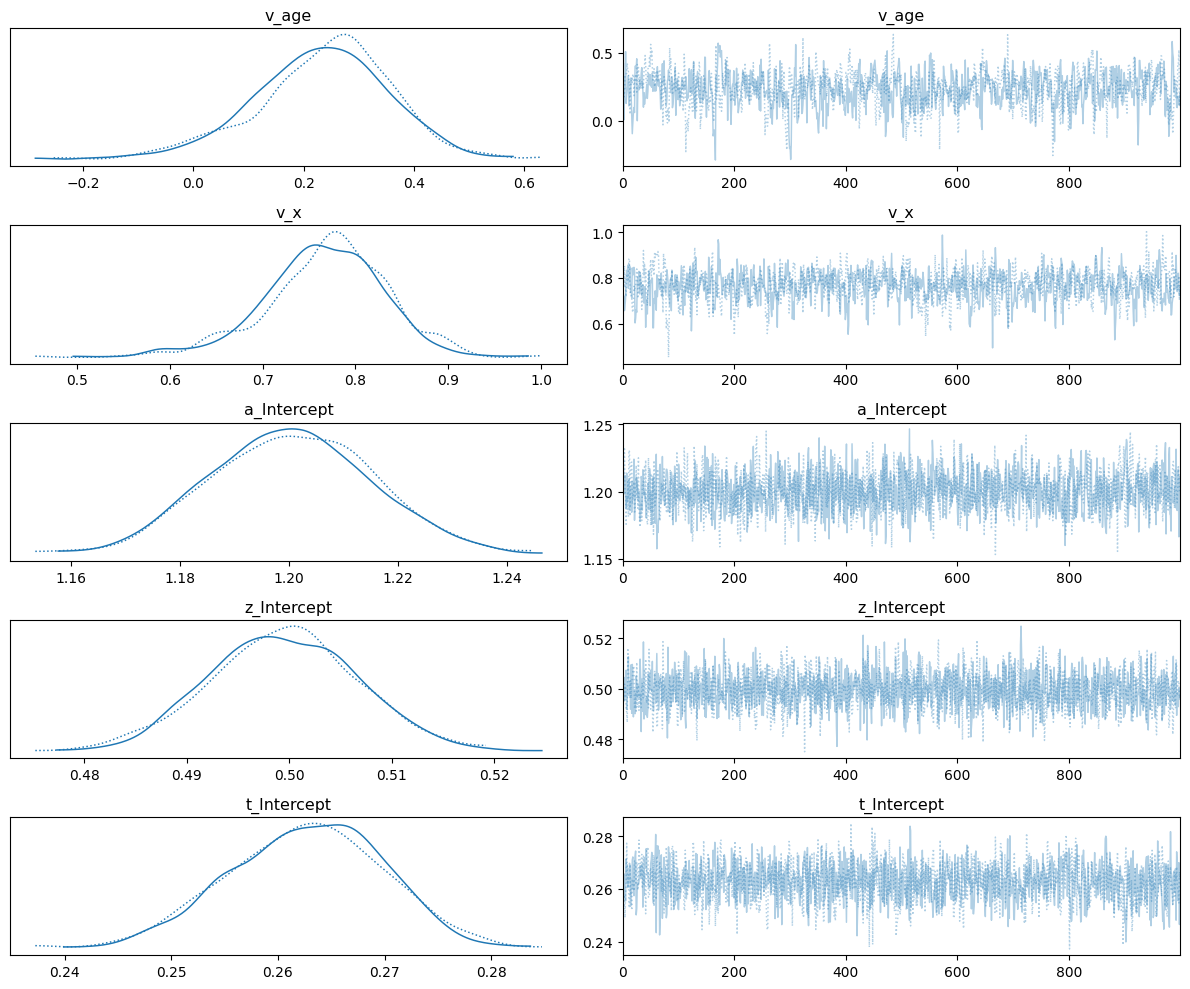

In [21]:
az.plot_trace(idata_B, var_names=["v_age", "v_x", "a_Intercept", "z_Intercept", "t_Intercept"])
plt.tight_layout();

No posterior_predictive samples found. Generating posterior_predictive samples using the provided InferenceData object and the original data. This will modify the provided InferenceData object, or if not provided, the traces object stored inside the model.


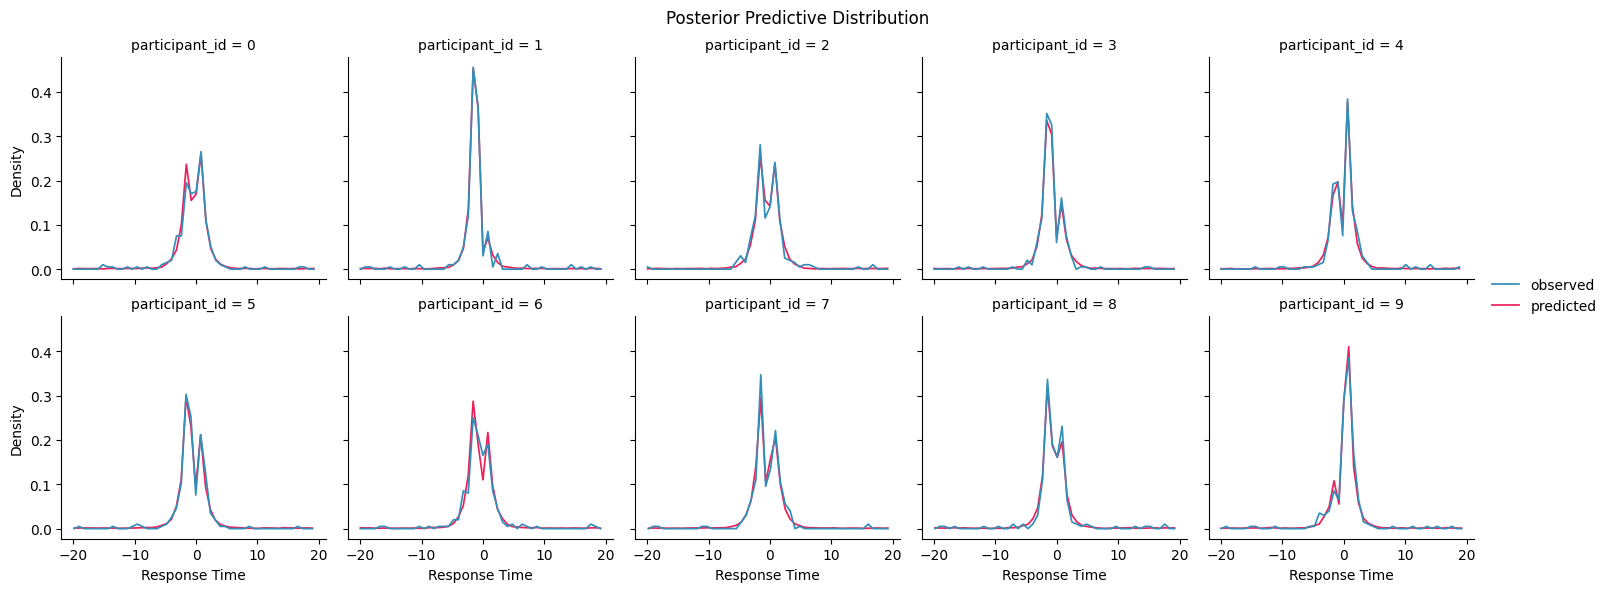

In [22]:
hssm.plotting.plot_predictive(model_B, col="participant_id", col_wrap=5)

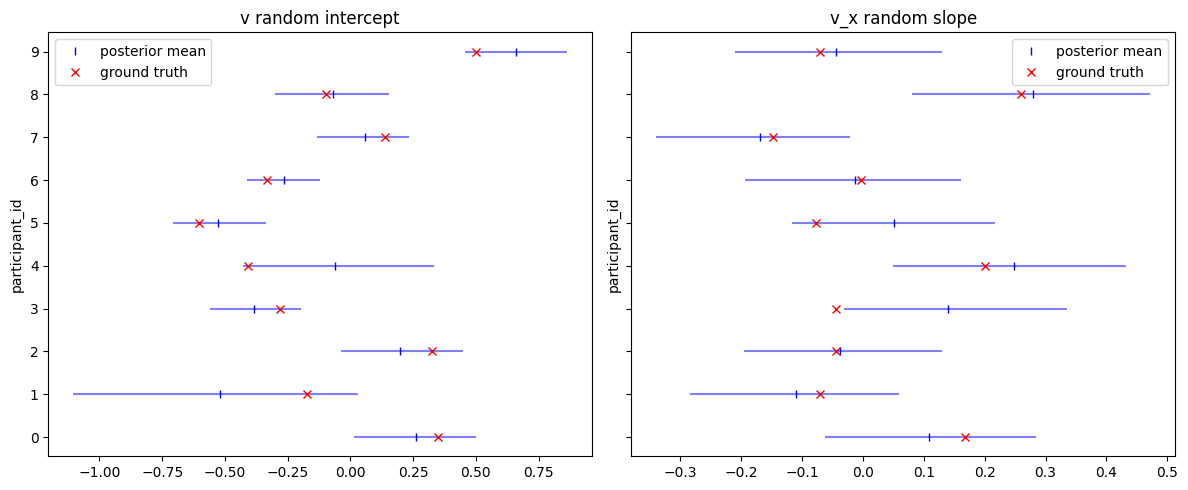

In [23]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_x|participant_id", v_slope_p, "v_x random slope"),
    ],
):
    post = idata_B.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, hdi_prob=0.95)[param_name].values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()

## Variant C: interaction

Same as B, but the effect of `x` on drift rate is allowed to depend on `age`.

a, z, t remain global scalars.

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.
Model initialized successfully.


/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
Sampling: [rt,response]


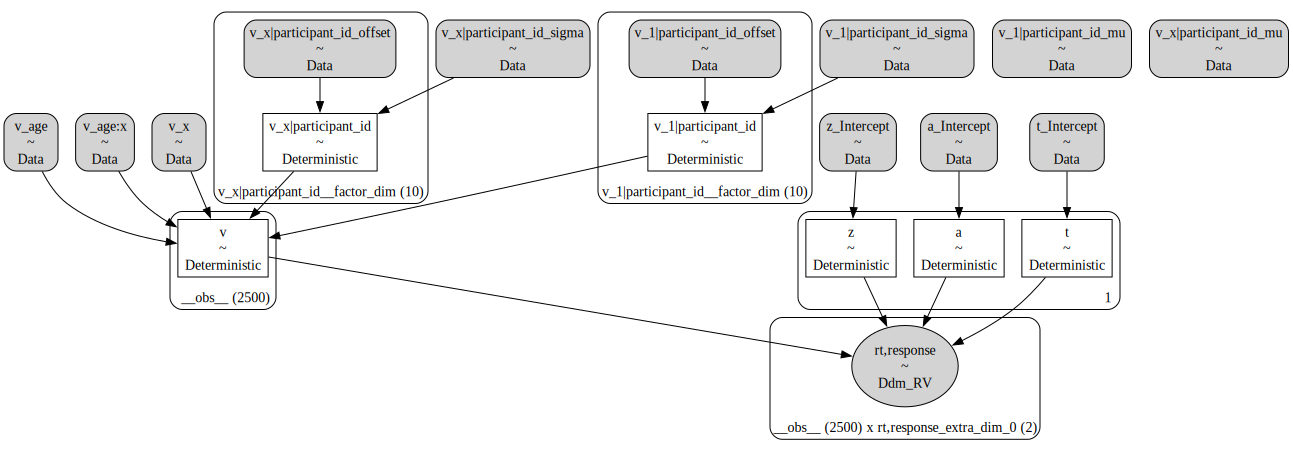

In [24]:
# true coefficients for variant C
beta_v_x = 0.8
beta_v_age = 0.4
beta_v_age_x = 0.3

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)

v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_C_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[{"name": "v", "formula": "v ~ 0 + age + x + age:x + (1 + x | participant_id)"}],
    noncentered=True,
)

# Use do-operator: intervene on regression coefficients and random effects
synth_idata_C, synth_model_C = model_C_gen.sample_do(
    params={
        "v_age": beta_v_age,
        "v_x": beta_v_x,
        "v_age:x": beta_v_age_x,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_x|participant_id_mu": 0.0,
        "v_x|participant_id_sigma": sigma_v_slope,
        "v_x|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    return_model=True,
)

pm.model_to_graphviz(synth_model_C)

In [25]:
synth_df_C = hssm.utils.predictive_idata_to_dataframe(
    synth_idata_C, predictive_group="prior_predictive"
)

data_C = covariates.copy()
data_C["rt"] = synth_df_C["rt"].values
data_C["response"] = synth_df_C["response"].values
data_C.to_csv("sim_variant_C.csv", index=False)

In [26]:
data_C = pd.read_csv("sim_variant_C.csv")

model_C = hssm.HSSM(
    data=data_C,
    model="ddm",
    global_formula="y ~ 1",
    include=[{"name": "v", "formula": "v ~ 0 + age + x + age:x + (1 + x | participant_id)"}],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.
Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + age + x + age:x + (1 + x | participant_id)
    Priors:
        v_age ~ Normal(mu: 0.0, sigma: 0.25)
        v_x ~ Normal(mu: 0.0, sigma: 0.25)
        v_age:x ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_x|participant_id ~ Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)
    Link: identity
    Explic

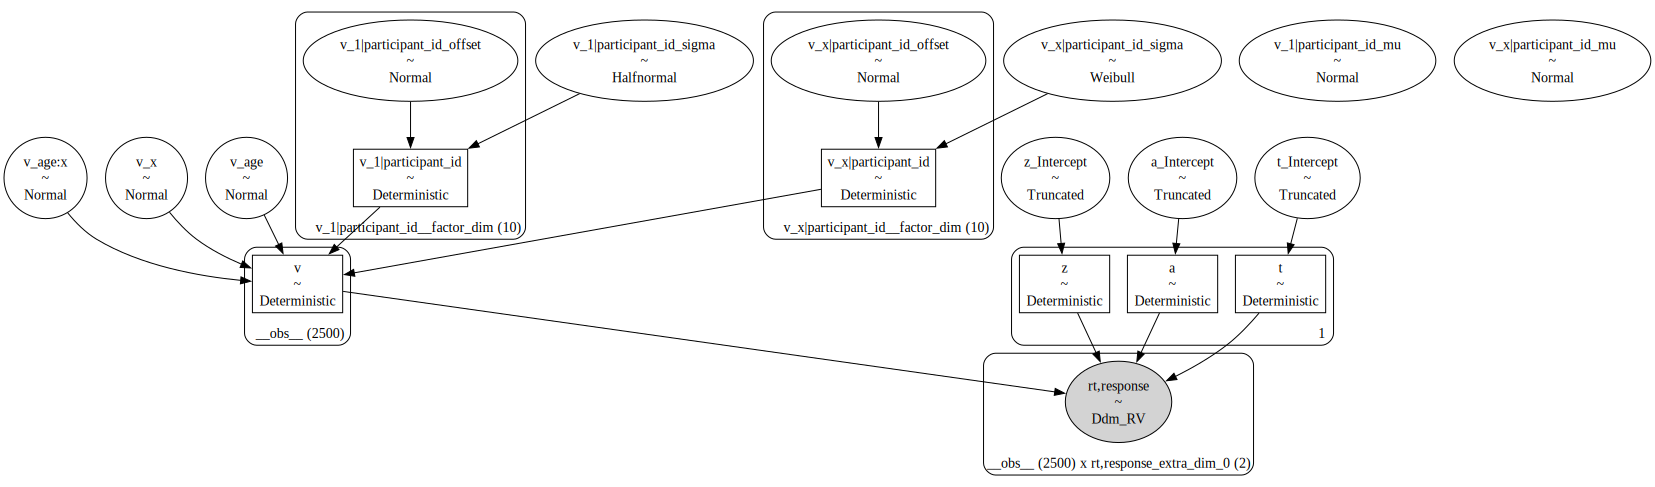

In [27]:
print(model_C)
model_C.graph()

In [28]:
idata_C = model_C.sample(draws=1000, tune=500, chains=2, target_accept=0.9)

Using default initvals. 



Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [v_age, v_x, v_age:x, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_x|participant_id_mu, v_x|participant_id_sigma, v_x|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]
/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 165 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
100%|██████████| 2000/2000 [00:01<00:00, 1407.81it/s]


Full summary to see participant-wise parameters:

In [29]:
az.summary(idata_C)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_Intercept,0.496,0.007,0.482,0.509,0.000,0.000,2714.0,1275.0,1.00
v_1|participant_id_mu,1.895,2.927,-3.336,7.463,0.055,0.079,2870.0,1351.0,1.00
v_x|participant_id_mu,-0.002,0.240,-0.445,0.454,0.005,0.006,2781.0,1443.0,1.00
v_age,0.400,0.107,0.203,0.597,0.004,0.003,677.0,829.0,1.00
v_age:x,0.187,0.094,0.009,0.353,0.003,0.003,1163.0,1072.0,1.00
v_1|participant_id_offset[0],-0.475,0.321,-1.065,0.111,0.009,0.008,1144.0,1398.0,1.00
v_1|participant_id_offset[1],-0.939,0.646,-2.115,0.278,0.022,0.013,844.0,993.0,1.00
v_1|participant_id_offset[2],0.982,0.459,0.167,1.862,0.019,0.010,603.0,1113.0,1.01
v_1|participant_id_offset[3],-0.451,0.267,-0.980,0.022,0.007,0.007,1516.0,1569.0,1.00
v_1|participant_id_offset[4],-0.308,0.510,-1.230,0.667,0.019,0.010,739.0,1307.0,1.00


In [30]:
az.summary(idata_C, var_names=["v_age", "v_x", "v_age:x", "a_Intercept", "z_Intercept", "t_Intercept"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_age,0.400,0.107,0.203,0.597,0.004,0.003,677.0,829.0,1.0
v_x,0.758,0.110,0.550,0.951,0.004,0.003,739.0,902.0,1.0
v_age:x,0.187,0.094,0.009,0.353,0.003,0.003,1163.0,1072.0,1.0
a_Intercept,1.200,0.015,1.172,1.229,0.000,0.000,2308.0,1478.0,1.0
z_Intercept,0.496,0.007,0.482,0.509,0.000,0.000,2714.0,1275.0,1.0
t_Intercept,0.250,0.007,0.237,0.262,0.000,0.000,1966.0,1529.0,1.0


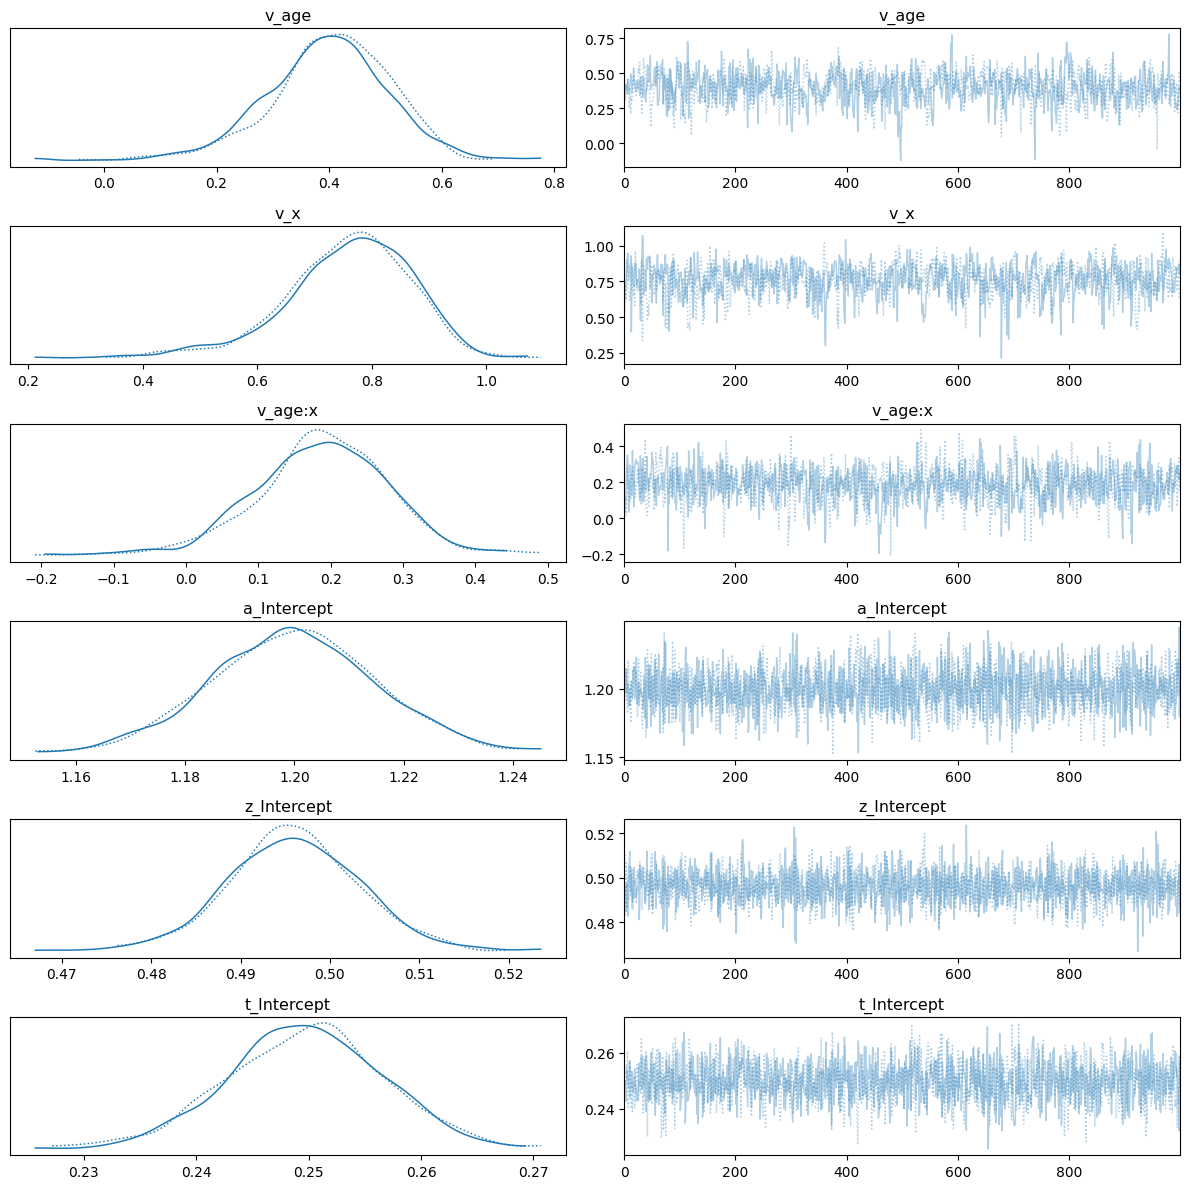

In [31]:
az.plot_trace(idata_C, var_names=["v_age", "v_x", "v_age:x", "a_Intercept", "z_Intercept", "t_Intercept"])
plt.tight_layout();

No posterior_predictive samples found. Generating posterior_predictive samples using the provided InferenceData object and the original data. This will modify the provided InferenceData object, or if not provided, the traces object stored inside the model.


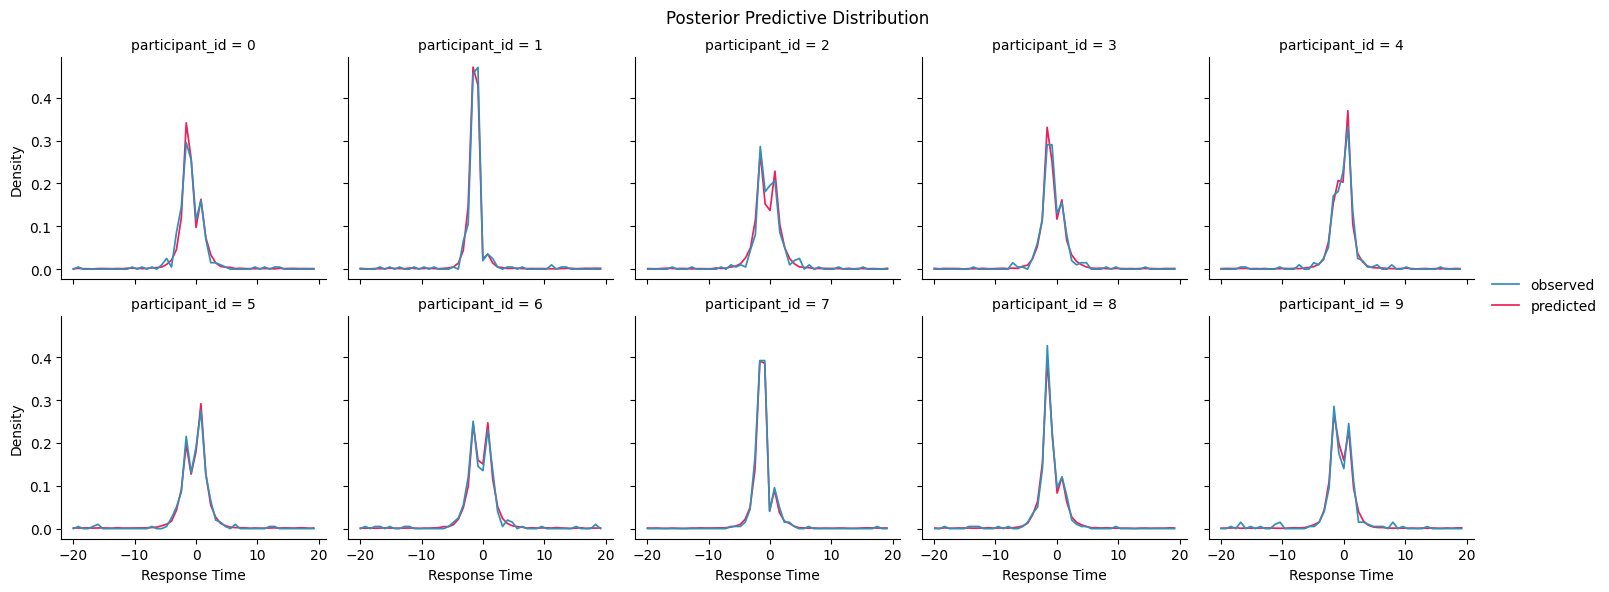

In [32]:
hssm.plotting.plot_predictive(model_C, col="participant_id", col_wrap=5)

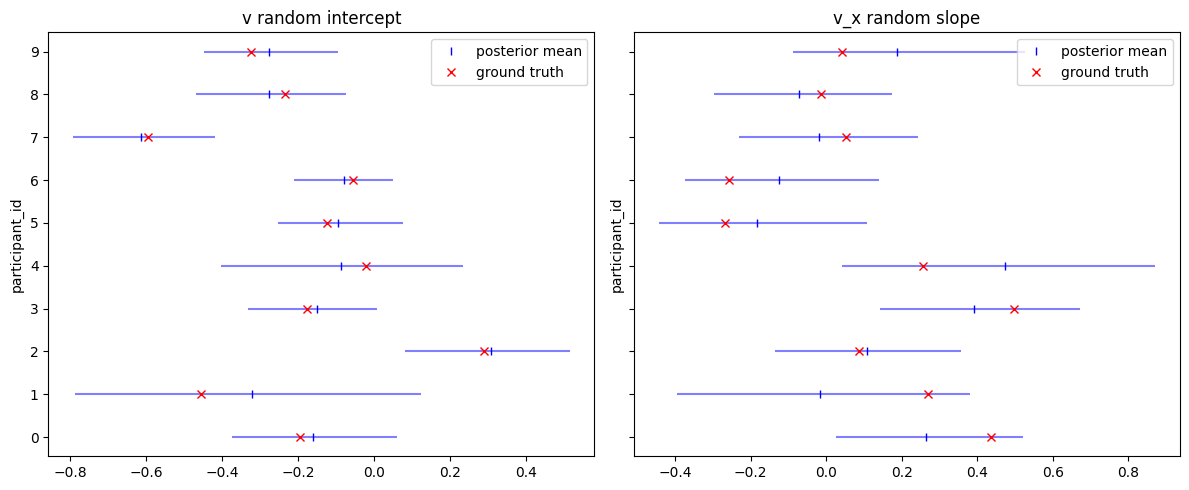

In [33]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_x|participant_id", v_slope_p, "v_x random slope"),
    ],
):
    post = idata_C.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, hdi_prob=0.95)[param_name].values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()

## Variant D: full hierarchy on every parameter

Same v regression as Variant A, but now `global_formula="y ~ 1 + (1 | participant_id)"` adds participant-level random intercepts to **a, z, t** as well.

This is the most realistic specification for real data but is slower to fit and adds nuisance participant-level parameters. The simulator now draws per-participant values for a, z, t to match.

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.
Model initialized successfully.


/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
Sampling: [rt,response]


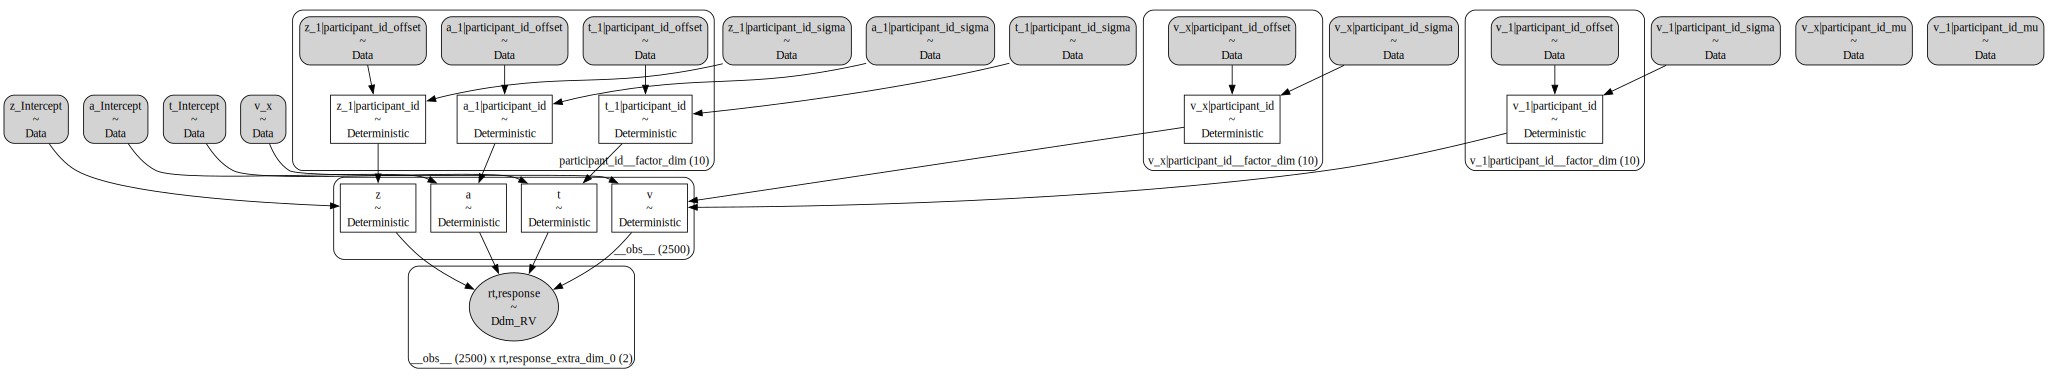

In [34]:
# Variant D: simulate with per-participant a, z, t
beta_v_x = 0.8

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)

# Per-participant a, z, t (centered on the scalar means used in A/B/C)
sigma_a, sigma_z, sigma_t = 0.15, 0.05, 0.05
a_p = a_true + rng.normal(0, sigma_a, n_participants)
z_p = np.clip(z_true + rng.normal(0, sigma_z, n_participants), 0.05, 0.95)
# t clipped to >= 0.001 (relaxed from the old 0.05 bound)
t_p = np.clip(t_true + rng.normal(0, sigma_t, n_participants), 0.001, None)

# Noncentered offsets, derived from the (possibly clipped) per-participant values
v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope
a_int_offset = (a_p - a_true) / sigma_a
z_int_offset = (z_p - z_true) / sigma_z
t_int_offset = (t_p - t_true) / sigma_t

# Build HSSM model with full hierarchy
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_D_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1 + (1 | participant_id)",
    include=[{"name": "v", "formula": "v ~ 0 + x + (1 + x | participant_id)"}],
    noncentered=True,
)

# Use do-operator: intervene on every regression coefficient and random effect
synth_idata_D, synth_model_D = model_D_gen.sample_do(
    params={
        "v_x": beta_v_x,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_x|participant_id_mu": 0.0,
        "v_x|participant_id_sigma": sigma_v_slope,
        "v_x|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "a_1|participant_id_sigma": sigma_a,
        "a_1|participant_id_offset": a_int_offset,
        "z_Intercept": z_true,
        "z_1|participant_id_sigma": sigma_z,
        "z_1|participant_id_offset": z_int_offset,
        "t_Intercept": t_true,
        "t_1|participant_id_sigma": sigma_t,
        "t_1|participant_id_offset": t_int_offset,
    },
    draws=1,
    return_model=True,
)

pm.model_to_graphviz(synth_model_D)

In [35]:
synth_df_D = hssm.utils.predictive_idata_to_dataframe(
    synth_idata_D, predictive_group="prior_predictive"
)

data_D = covariates.copy()
data_D["rt"] = synth_df_D["rt"].values
data_D["response"] = synth_df_D["response"].values
data_D.to_csv("sim_variant_D.csv", index=False)
data_D.head()

,participant_id,x,age,rt,response
0,0,0.125730,-0.858436,1.197794,1.0
1,0,-0.132105,-0.858436,0.574245,-1.0
2,0,0.640423,-0.858436,1.043878,1.0
3,0,0.104900,-0.858436,3.183811,1.0
4,0,-0.535669,-0.858436,0.810017,-1.0


In [36]:
data_D = pd.read_csv("sim_variant_D.csv")

model_D = hssm.HSSM(
    data=data_D,
    model="ddm",
    global_formula="y ~ 1 + (1 | participant_id)",
    include=[{"name": "v", "formula": "v ~ 0 + x + (1 + x | participant_id)"}],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.
Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + x + (1 + x | participant_id)
    Priors:
        v_x ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_x|participant_id ~ Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1 + (1 | participant_id)
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
        a_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1 + (1 | participant_id)
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
        z_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
 

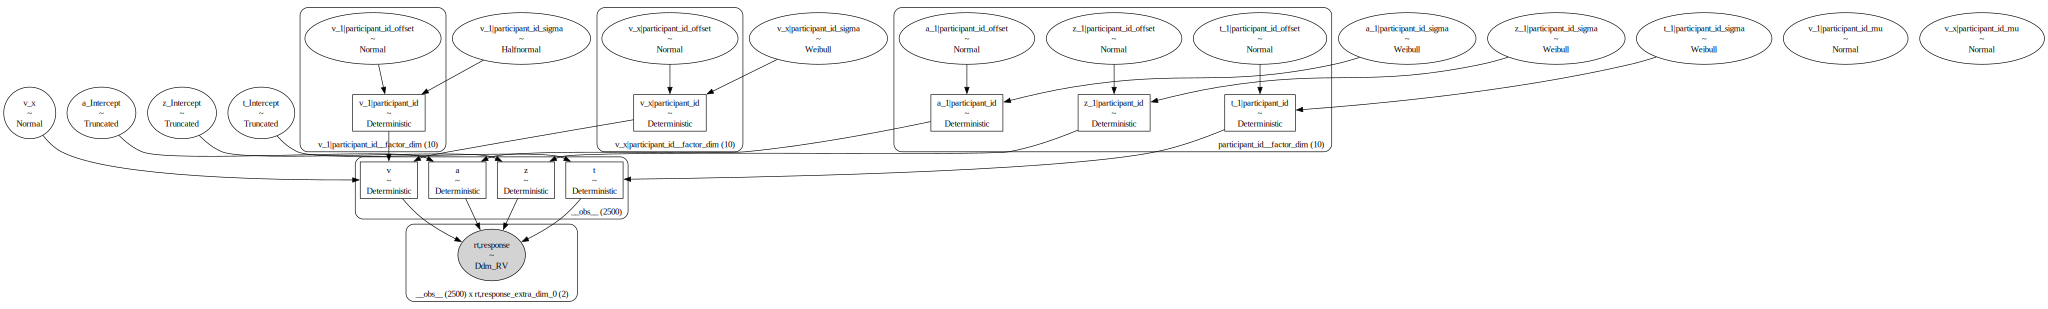

In [37]:
print(model_D)
model_D.graph()

In [38]:
idata_D = model_D.sample(draws=1000, tune=500, chains=2, target_accept=0.9)

Using default initvals. 



Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [v_x, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_x|participant_id_mu, v_x|participant_id_sigma, v_x|participant_id_offset, a_Intercept, a_1|participant_id_sigma, a_1|participant_id_offset, z_Intercept, z_1|participant_id_sigma, z_1|participant_id_offset, t_Intercept, t_1|participant_id_sigma, t_1|participant_id_offset]
/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 167 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
100%|██████████| 2000/2000 [00:01<00:00, 1352.64it/s]


In [39]:
az.summary(idata_D)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_1|participant_id_mu,2.021,2.868,-3.195,7.468,0.051,0.063,3112.0,1645.0,1.01
z_1|participant_id_sigma,0.041,0.017,0.014,0.074,0.001,0.001,517.0,1055.0,1.01
a_1|participant_id_offset[0],-0.523,0.428,-1.293,0.330,0.015,0.010,788.0,975.0,1.00
a_1|participant_id_offset[1],-0.400,0.426,-1.204,0.389,0.015,0.010,840.0,1217.0,1.00
a_1|participant_id_offset[2],0.112,0.435,-0.669,0.955,0.015,0.010,844.0,1032.0,1.00
...,...,...,...,...,...,...,...,...,...
z_1|participant_id_offset[5],-0.703,0.624,-1.868,0.411,0.015,0.015,1776.0,1515.0,1.00
z_1|participant_id_offset[6],-1.485,0.656,-2.833,-0.392,0.017,0.014,1437.0,1440.0,1.00
z_1|participant_id_offset[7],0.417,0.580,-0.562,1.602,0.014,0.011,1801.0,1504.0,1.00
z_1|participant_id_offset[8],0.331,0.605,-0.859,1.477,0.015,0.015,1530.0,1507.0,1.00


In [40]:
az.summary(idata_D, var_names=[
    "v_x",
    "a_Intercept", "a_1|participant_id_sigma",
    "z_Intercept", "z_1|participant_id_sigma",
    "t_Intercept", "t_1|participant_id_sigma",
])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_x,0.783,0.090,0.617,0.945,0.004,0.003,616.0,720.0,1.00
a_Intercept,1.192,0.058,1.091,1.309,0.002,0.002,549.0,598.0,1.00
a_1|participant_id_sigma,0.166,0.047,0.088,0.245,0.002,0.002,900.0,1298.0,1.00
z_Intercept,0.489,0.016,0.459,0.517,0.001,0.001,898.0,1126.0,1.00
z_1|participant_id_sigma,0.041,0.017,0.014,0.074,0.001,0.001,517.0,1055.0,1.01
t_Intercept,0.258,0.023,0.216,0.302,0.001,0.001,569.0,791.0,1.00
t_1|participant_id_sigma,0.068,0.021,0.037,0.110,0.001,0.001,861.0,1163.0,1.00


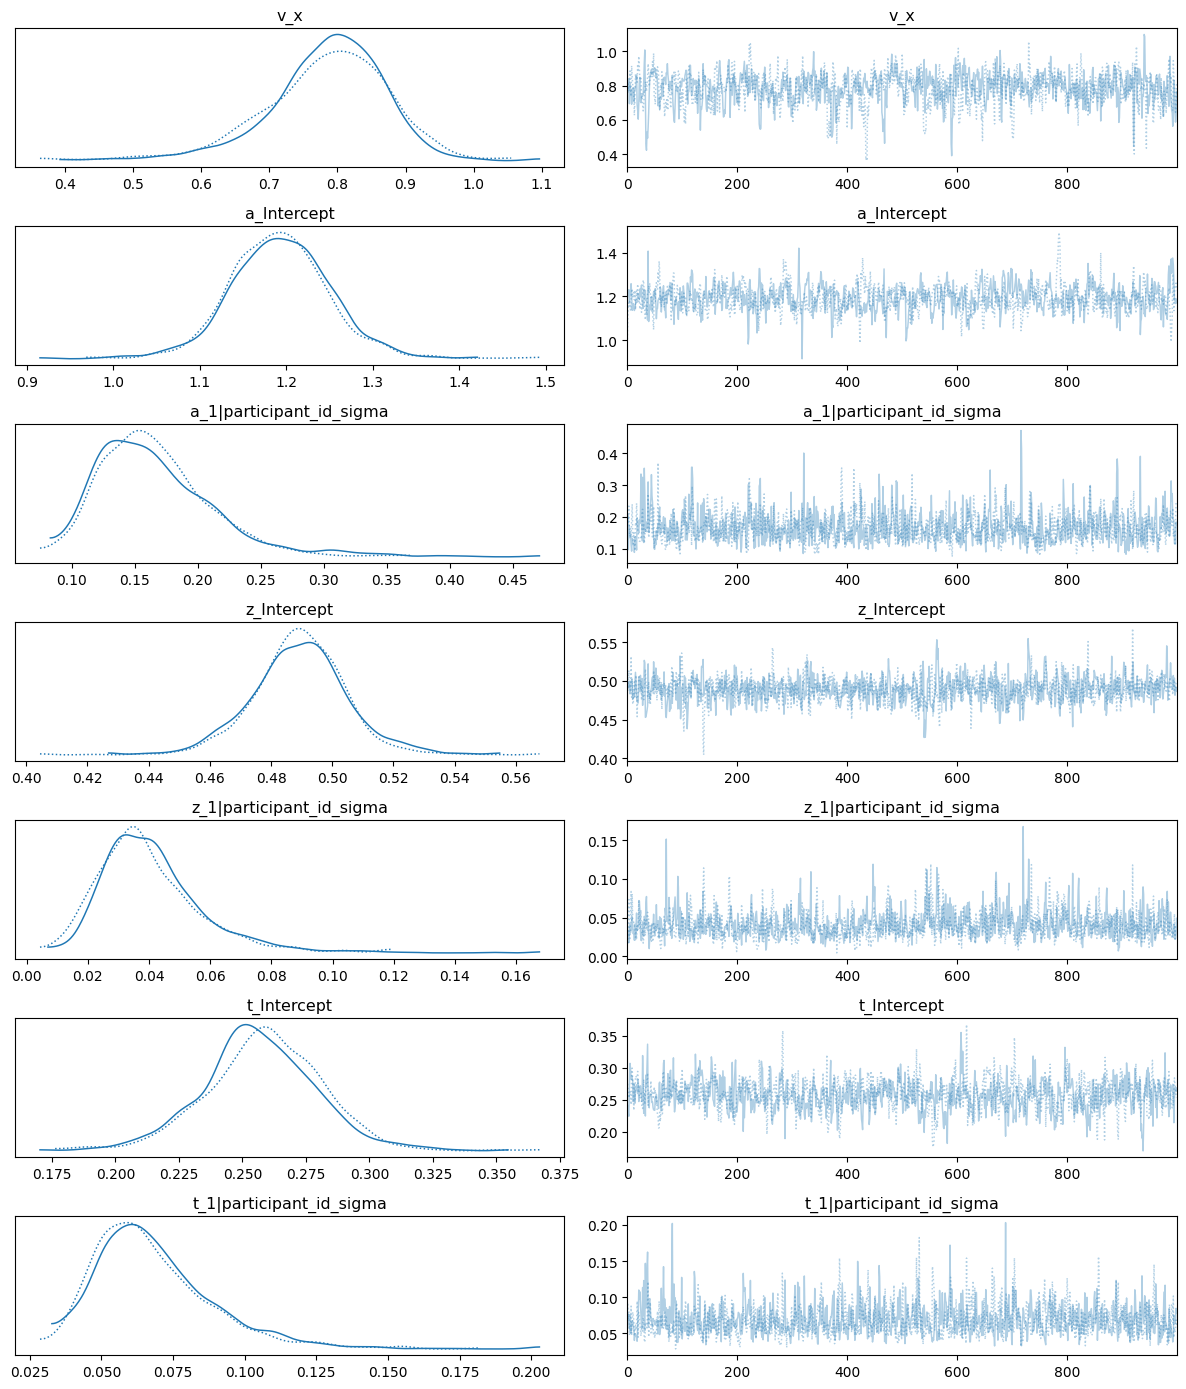

In [41]:
az.plot_trace(idata_D, var_names=[
    "v_x",
    "a_Intercept", "a_1|participant_id_sigma",
    "z_Intercept", "z_1|participant_id_sigma",
    "t_Intercept", "t_1|participant_id_sigma",
])
plt.tight_layout();

No posterior_predictive samples found. Generating posterior_predictive samples using the provided InferenceData object and the original data. This will modify the provided InferenceData object, or if not provided, the traces object stored inside the model.


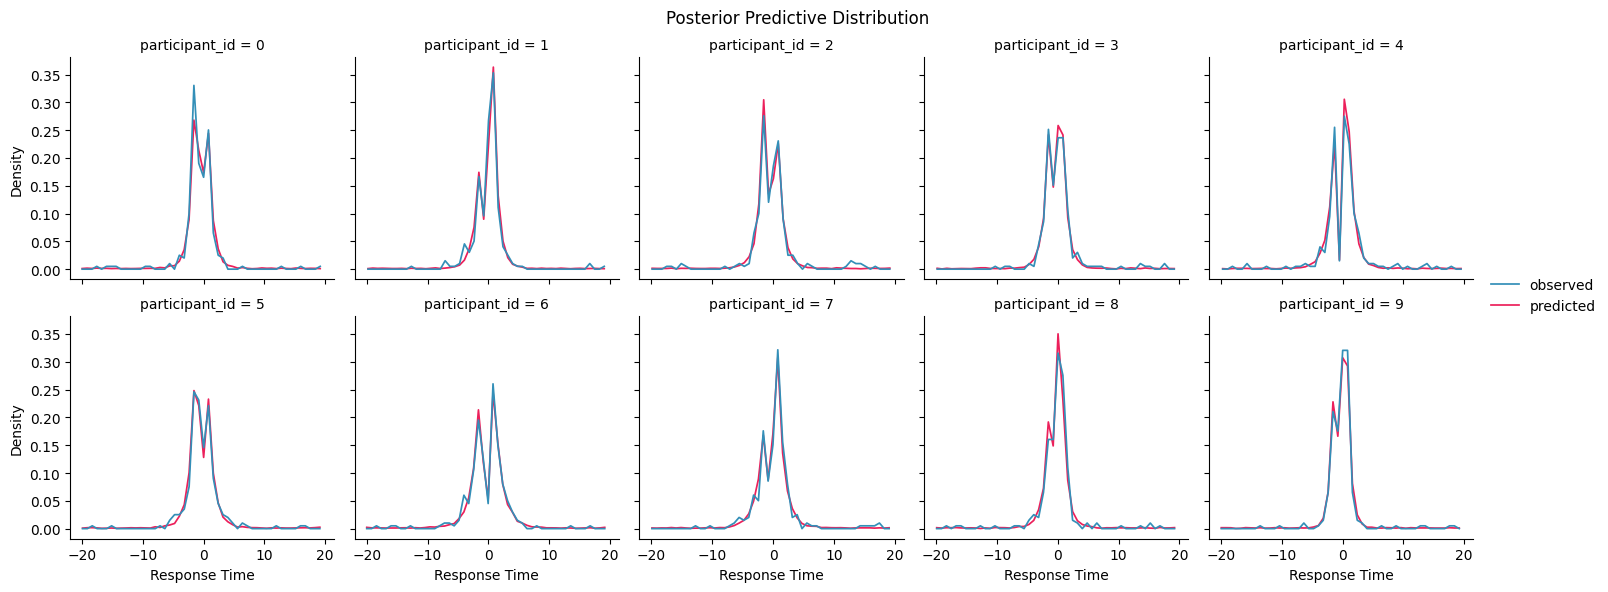

In [42]:
hssm.plotting.plot_predictive(model_D, col="participant_id", col_wrap=5)

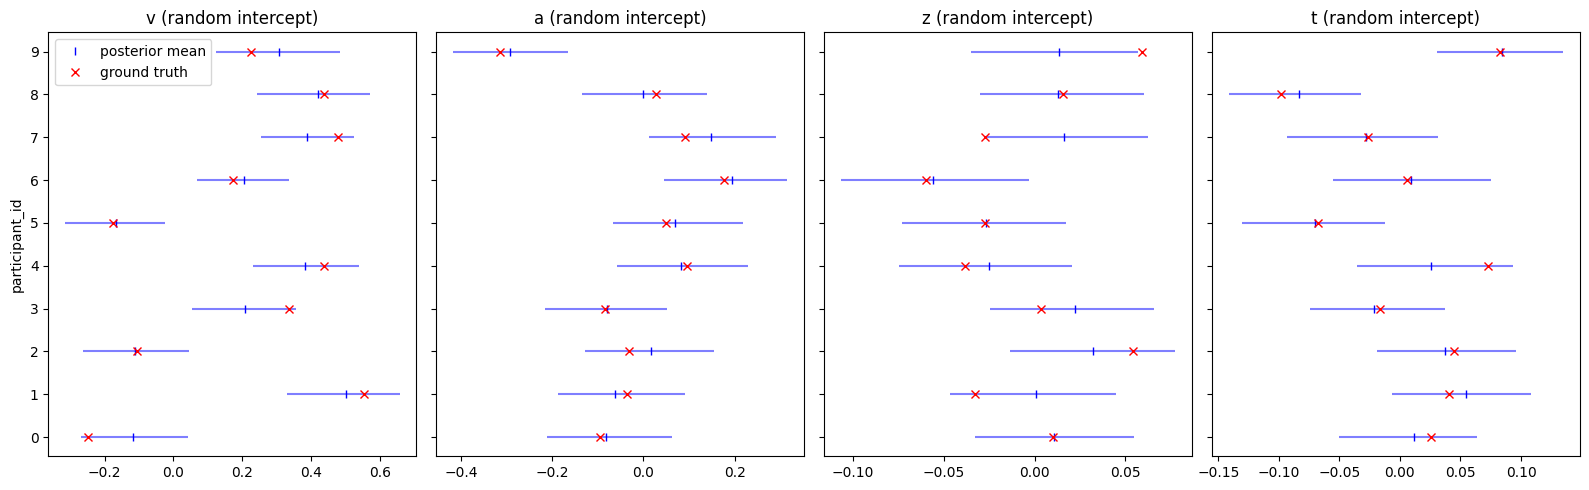

In [43]:
# Participant-wise parameter recovery for all DDM parameters
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v (random intercept)"),
        ("a_1|participant_id", a_p - a_true, "a (random intercept)"),
        ("z_1|participant_id", z_p - z_true, "z (random intercept)"),
        ("t_1|participant_id", t_p - t_true, "t (random intercept)"),
    ],
):
    post = idata_D.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, hdi_prob=0.95)[param_name].values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    if ax is axes[0]:
        ax.set_ylabel("participant_id")
        ax.legend()

plt.tight_layout()